In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


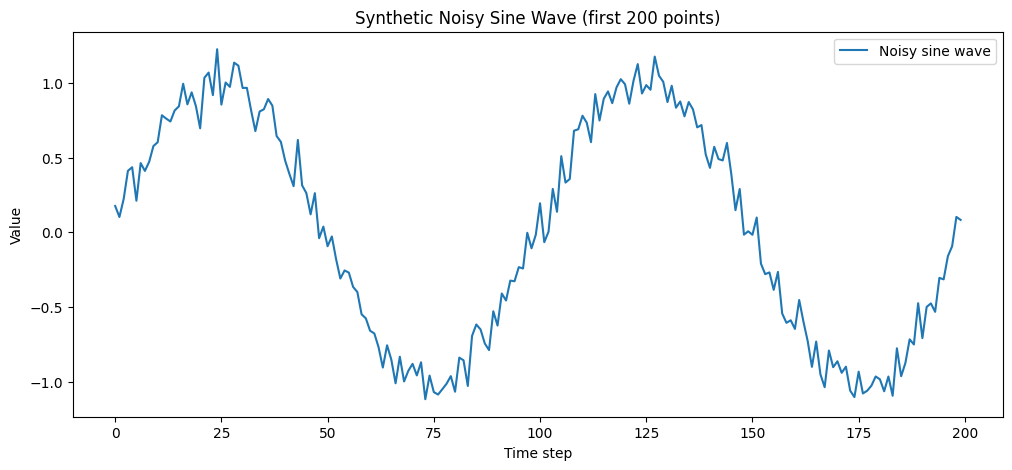

In [3]:
# Generating  a synthetic sine-wave time series with noise
np.random.seed(0)
T = 1000
t = np.linspace(0, 20*np.pi, T)             # time steps
data = np.sin(t) + 0.1*np.random.randn(T)   # sine wave + noise

plt.figure(figsize=(12,5))
plt.plot(data[:200], label='Noisy sine wave')
plt.title("Synthetic Noisy Sine Wave (first 200 points)")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.show()


In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, dilation=dilation)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, dilation=dilation)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def forward(self, x):
        # Compute left padding so conv remains causal (no lookahead)
        pad = (self.kernel_size - 1) * self.dilation

        # First causal convolution (pad only on left)
        out = F.pad(x, (pad, 0))
        out = F.relu(self.conv1(out))

        # Second causal convolution
        out = F.pad(out, (pad, 0))
        out = self.conv2(out)

        # Add residual (identity) connection
        res = x if self.downsample is None else self.downsample(x)
        return F.relu(out + res)

class TCNModel(nn.Module):
    def __init__(self, num_inputs=1, num_channels=[16, 16, 16], kernel_size=2):
        """
        num_channels: list of output channels for each TCN layer/block.
        kernel_size: filter width of each 1D conv.
        """
        super().__init__()
        layers = []
        in_ch = num_inputs
        # Create a stack of ResidualBlocks with dilations 1, 2, 4...
        for i, ch in enumerate(num_channels):
            dilation = 2 ** i      # exponentially increasing dilations
            layers.append(ResidualBlock(in_ch, ch, kernel_size, dilation))
            in_ch = ch
        self.tcn = nn.Sequential(*layers)
        # Final linear layer to produce a single output value
        self.linear = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        """
        x has shape (batch_size, channels=1, seq_len).
        """
        out = self.tcn(x)            # (batch, channels, seq_len)
        out = out[:, :, -1]          # take the last time step's features
        out = self.linear(out)       # (batch, 1)
        return out.squeeze(-1)       # return shape (batch,) 


In [5]:
# Convert the numpy data into PyTorch tensors
series = torch.from_numpy(data).float()

# Prepare sliding windows
window_size = 30
X, Y = [], []
for i in range(len(series) - window_size):
    x = series[i:i+window_size]
    y = series[i+window_size]     # next value to predict
    X.append(x.unsqueeze(0))      # shape (1, window_size)
    Y.append(y)
X = torch.stack(X)  # shape (num_samples, 1, window_size)
Y = torch.stack(Y)  # shape (num_samples,)

# Split into training and test sets
train_size = int(0.8 * len(X))
X_train, Y_train = X[:train_size], Y[:train_size]
X_test,  Y_test  = X[train_size:], Y[train_size:]

train_ds = TensorDataset(X_train, Y_train)
test_ds  = TensorDataset(X_test,  Y_test)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=16)


In [6]:
# Initialize model, loss, optimizer
model = TCNModel(num_inputs=1, num_channels=[16,16,16], kernel_size=2)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_preds = []
    for xb, _ in test_loader:
        test_preds.append(model(xb).unsqueeze(1))
    test_preds = torch.cat(test_preds).squeeze()
    test_loss = criterion(test_preds, Y_test).item()
print(f"Test MSE: {test_loss:.4f}")


Epoch 10/50, Loss: 0.0246
Epoch 20/50, Loss: 0.0164
Epoch 30/50, Loss: 0.0084
Epoch 40/50, Loss: 0.0097
Epoch 50/50, Loss: 0.0137
Test MSE: 0.0142
